# Heart Disease Prediction

**Created by Rahul Yadav**
# 1) Objective
A Machine Learning project that predicts whether a person is likely to have heart disease based on medical and health-related features.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Machine Learning
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Selection
- Model Training
- Model Evaluation
- Heart Disease Prediction

### Project Goal
The main goal of this project is to use machine learning techniques to analyze health-related data and predict the possibility of heart disease.

# 2) Import Required Libraries

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# 3) Load Dataset

In [126]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# 3) Data Understanding

In [127]:
# Size of Data sets
df.shape

(918, 12)

This dataset has **918** row and **12** columns.

In [128]:
# Information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [129]:
# Dataset Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [130]:
# Columns of Datasets
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [131]:
# Find of null value in dataset
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [132]:
# Find of duplcate Row in dataset
df.duplicated().sum()

np.int64(0)

# 4) Exploratory Data Analysis (EDA)

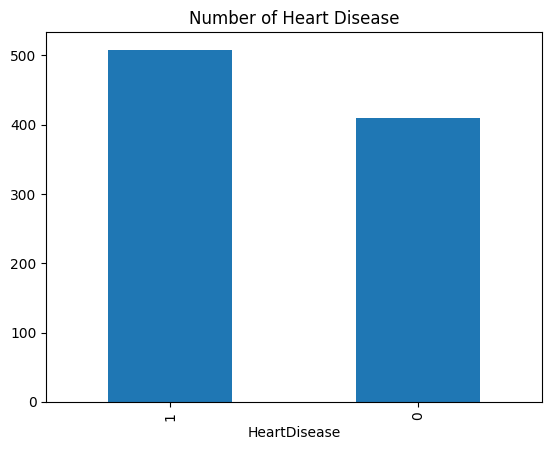

In [133]:
df['HeartDisease'].value_counts().plot(kind= 'bar')
plt.title('Number of Heart Disease')
plt.show()

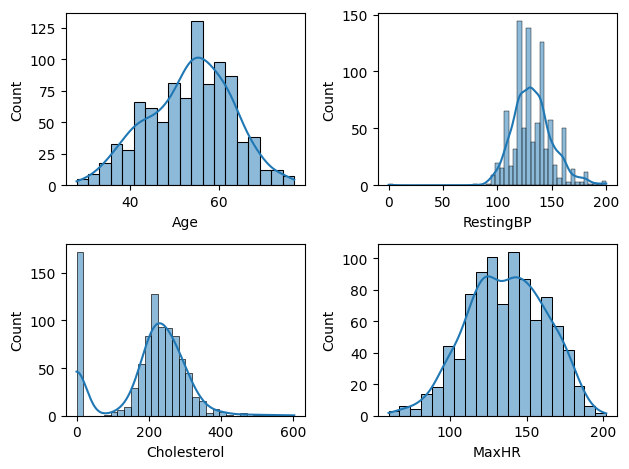

In [134]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [135]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [136]:
ch_mean  = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [137]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [138]:
resting_bp_mean = df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,ch_mean)
df['RestingBP'] = df['RestingBP'].round(2)

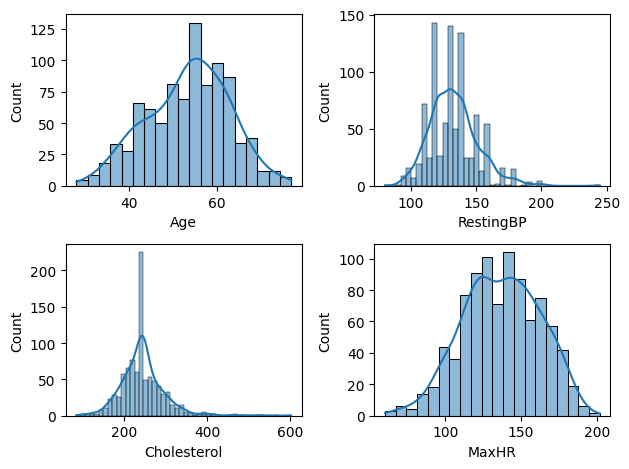

In [139]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

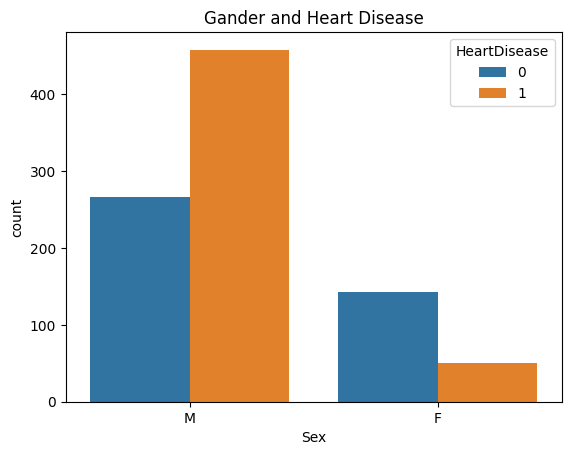

In [140]:
sns.countplot(x  = df['Sex'],hue = df['HeartDisease'])
plt.title('Gander and Heart Disease')
plt.show()

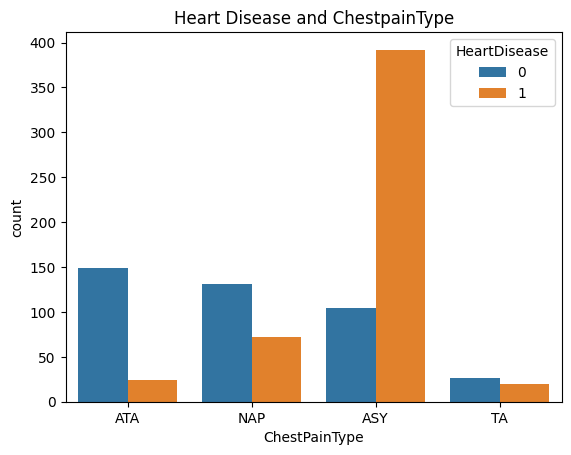

In [141]:
sns.countplot(x  = df['ChestPainType'],hue =df['HeartDisease'])
plt.title('Heart Disease and ChestpainType')
plt.show()

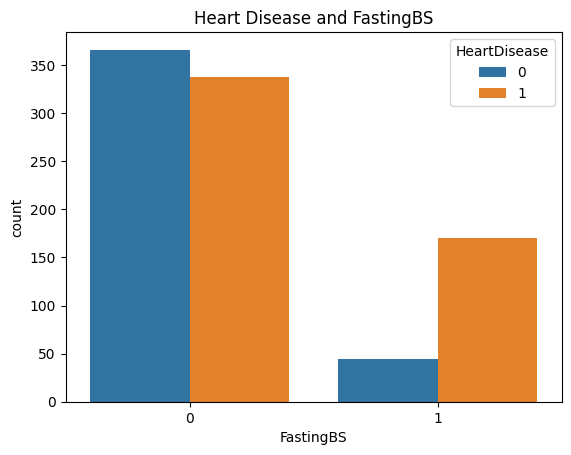

In [142]:
sns.countplot(x  = df['FastingBS'],hue =df['HeartDisease'])
plt.title('Heart Disease and FastingBS')
plt.show()

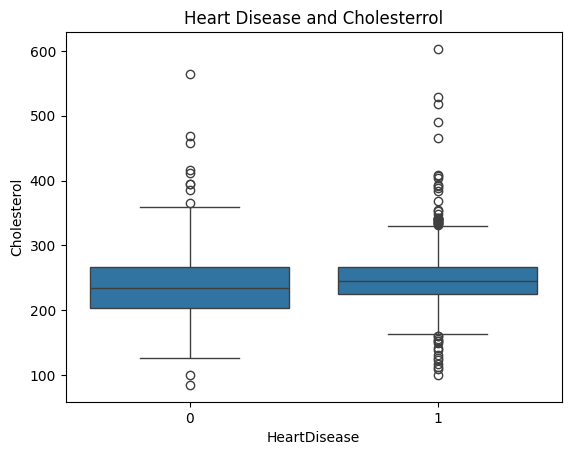

In [143]:
sns.boxplot(x = 'HeartDisease',y = 'Cholesterol',data = df)
plt.title('Heart Disease and Cholesterrol')
plt.show()

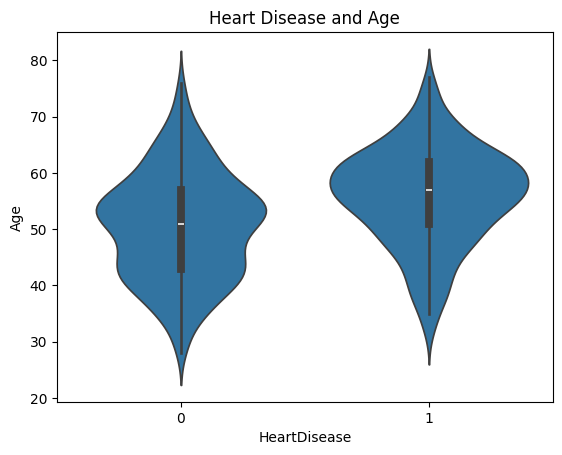

In [144]:
sns.violinplot(x = 'HeartDisease',y ='Age',data = df)
plt.title('Heart Disease and Age')
plt.show()

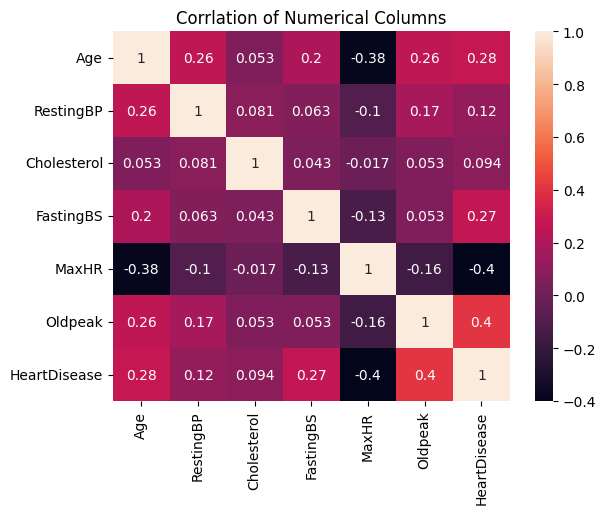

In [145]:
# corrlation of numerical columns
sns.heatmap(df.corr(numeric_only = True),annot = True)
plt.title('Corrlation of Numerical Columns')
plt.show()

# 5) Data preprocessing

In [146]:
df_encode = pd.get_dummies(df)

In [147]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [148]:
# Convert the datatype
df_encode = df_encode.astype(int)

In [149]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [150]:
# from sklearn.preprocessing import StandardScaler 
# Preprocessing of numerical data columns
numerical_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [151]:
df_encode.shape

(918, 21)

In [152]:
df_encode.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,-1.083616e-16,1.000545,-2.706015,-0.690629,0.051881,0.688318,2.491558
RestingBP,918.0,-4.044211e-16,1.000545,-2.869537,-0.689961,-0.145068,0.399826,6.066722
Cholesterol,918.0,1.035241e-16,1.000545,-2.993388,-0.572651,-0.009689,0.421915,6.727090
FastingBS,918.0,2.331155e-01,0.423046,0.000000,0.000000,0.000000,0.000000,1.000000
MaxHR,918.0,4.953675e-16,1.000545,-3.018469,-0.660578,0.046790,0.754157,2.561874
Oldpeak,918.0,8.514129e-17,1.000545,-2.748559,-0.727592,-0.727592,0.282891,5.335308
HeartDisease,918.0,5.533769e-01,0.497414,0.000000,0.000000,1.000000,1.000000,1.000000
Sex_F,918.0,2.102397e-01,0.407701,0.000000,0.000000,0.000000,0.000000,1.000000
Sex_M,918.0,7.897603e-01,0.407701,0.000000,1.000000,1.000000,1.000000,1.000000
ChestPainType_ASY,918.0,5.403050e-01,0.498645,0.000000,0.000000,1.000000,1.000000,1.000000


# 6) Feature Selection


In [153]:
X = df_encode.drop('HeartDisease',axis = 1)
y = df_encode['HeartDisease']

In [154]:
# split dataset with trian
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [155]:
X_train.shape,X_test.shape

((734, 20), (184, 20))

In [156]:
y_train.shape,y_test.shape

((734,), (184,))

In [157]:
scaler = StandardScaler()
X_train_Scaler = scaler.fit_transform(X_train)
X_test_Scaler = scaler.fit_transform(X_test)

# 7)Model Training

# 1 : LogisticRegression

In [158]:
linear_model = LogisticRegression()
linear_model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [159]:
y_pred_Linear = linear_model.predict(X_test)


In [160]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred_Linear))
print("F1 Score: ",f1_score(y_test,y_pred_Linear))

Accuracy Score:  0.8641304347826086
F1 Score:  0.8792270531400966


In [161]:
confusion_matrix(y_test,y_pred_Linear)

array([[68,  9],
       [16, 91]])

In [162]:
print(classification_report(y_test,y_pred_Linear))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



# 2: KNeighborsClassifier

In [163]:
KN_model = KNeighborsClassifier()
KN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [164]:
y_pred_KN = KN_model.predict(X_test)

In [165]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred_KN))
print("F1 Score: ",f1_score(y_test,y_pred_KN))

Accuracy Score:  0.8586956521739131
F1 Score:  0.875


In [166]:
confusion_matrix(y_test,y_pred_KN)

array([[67, 10],
       [16, 91]])

In [167]:
print(classification_report(y_test,y_pred_KN))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



# 3: naive_bayes GaussianNB

In [168]:
NB_model = GaussianNB()
NB_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [169]:
y_pred_NB = NB_model.predict(X_test)

In [170]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred_NB))
print("F1 Score: ",f1_score(y_test,y_pred_NB))


Accuracy Score:  0.842391304347826
F1 Score:  0.8557213930348259


In [171]:
confusion_matrix(y_test,y_pred_NB)

array([[69,  8],
       [21, 86]])

In [172]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83        77
           1       0.91      0.80      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



# 4:Decision Tree Classifier

In [173]:
DT_model  = DecisionTreeClassifier()
DT_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [174]:
y_pred_DT=DT_model.predict(X_test)

In [175]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred_DT))
print("F1 Score: ",f1_score(y_test,y_pred_DT))


Accuracy Score:  0.8043478260869565
F1 Score:  0.82


In [176]:
confusion_matrix(y_test,y_pred_DT)

array([[66, 11],
       [25, 82]])

In [177]:
print(classification_report(y_test,y_pred_DT))

              precision    recall  f1-score   support

           0       0.73      0.86      0.79        77
           1       0.88      0.77      0.82       107

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.82      0.80      0.81       184



# 5: Support vector Classifier

In [178]:
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [179]:
y_pred_svm = svm_model.predict(X_test)

In [180]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred_svm))
print("F1 Score: ",f1_score(y_test,y_pred_svm))

Accuracy Score:  0.8478260869565217
F1 Score:  0.8679245283018868


In [181]:
confusion_matrix(y_test,y_pred_svm)

array([[64, 13],
       [15, 92]])

In [182]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        77
           1       0.88      0.86      0.87       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.85      0.85       184



# 8) Model Evaluation

In [183]:
models   = {
    "logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "Naive Byeas" : GaussianNB(),
    "Decision tree" : DecisionTreeClassifier(),
    "SVM": SVC()
}

In [184]:
result = []

In [185]:
for name,model in models.items():
  model.fit(X_train_Scaler,y_train)
  y_pred = model.predict(X_test_Scaler)
  acc = accuracy_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  result.append({
      'model' : name,
      'Accuracy' : round(acc,4),
      'F1 Score' : round(f1,4)
  })



In [186]:
result

[{'model': 'logistic Regression', 'Accuracy': 0.875, 'F1 Score': 0.89},
 {'model': 'KNN', 'Accuracy': 0.8533, 'F1 Score': 0.8708},
 {'model': 'Naive Byeas', 'Accuracy': 0.8315, 'F1 Score': 0.8458},
 {'model': 'Decision tree', 'Accuracy': 0.8261, 'F1 Score': 0.8384},
 {'model': 'SVM', 'Accuracy': 0.8641, 'F1 Score': 0.8804}]

**Model Evaluation** Five classification models were evaluated using Accuracy and F1 Score. Logistic Regression achieved the highest Accuracy **(87.50%)** and F1 Score **(89.00%)** among the tested models. Therefore, it can be selected for further analysis.

In [188]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84        77
           1       0.90      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184

[[67 10]
 [15 92]]


In [187]:
import joblib
joblib.dump(models['logistic Regression'],'logisticRegression.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columms.pkl')

['columms.pkl']